# 🌿 Cassava Leaf Disease Classification
## Notebook 03: Feature Engineering

**ML Coursework Project**

---

### Notebook Objectives
1. Extract deep features using pre-trained CNN (VGG16/ResNet50)
2. Apply PCA for dimensionality reduction
3. Analyze explained variance
4. Visualize features using t-SNE
5. Save extracted features for traditional ML models

## 1. Import Libraries

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import json
import pickle

# Image processing
import cv2

# Deep Learning
import torch
import torch.nn as nn
from torchvision.models import vgg16, resnet50, VGG16_Weights, ResNet50_Weights

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

# System info
import platform

# Set style
plt.style.use('seaborn-v0_8-whitegrid')

# Check hardware/runtime
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")
print(f"OS: {platform.system()} {platform.release()}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA runtime: {torch.version.cuda}")
else:
    print("⚠️ No CUDA GPU detected by PyTorch.")

print(f"Using device: {device}")

print("\n✅ Libraries imported successfully!")

PyTorch version: 2.11.0+cu128
OS: Windows 11
CUDA available: True
GPU count: 1
Active GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA runtime: 12.8
Using device: cuda

✅ Libraries imported successfully!


## 2. Load Configuration and Data Split

In [2]:
# Load preprocessing config
with open('outputs/preprocessing_config.json', 'r') as f:
    config = json.load(f)

# Load train/val split
with open('outputs/train_val_split.pkl', 'rb') as f:
    split_data = pickle.load(f)

X_train_paths = np.array(split_data['X_train_paths'])
X_val_paths = np.array(split_data['X_val_paths'])
y_train = np.array(split_data['y_train'])
y_val = np.array(split_data['y_val'])

IMG_SIZE = config['img_size']
CLASSES = config['classes']
NUM_CLASSES = config['num_classes']

print(f"📊 Configuration Loaded:")
print(f"   - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"   - Classes: {CLASSES}")
print(f"   - Training samples: {len(X_train_paths):,}")
print(f"   - Validation samples: {len(X_val_paths):,}")

📊 Configuration Loaded:
   - Image size: 224x224
   - Classes: ['cbb', 'cbsd', 'cgm', 'cmd', 'healthy']
   - Training samples: 4,524
   - Validation samples: 1,132


## 3. Create Feature Extraction Model

In [3]:
def create_feature_extractor(model_name='vgg16', device='cpu'):
    """
    Create a feature extraction model using pre-trained CNN.
    
    The model extracts features from the last convolutional layer,
    which captures high-level visual patterns.
    
    Parameters:
    -----------
    model_name : str
        Either 'vgg16' or 'resnet50'
    
    Returns:
    --------
    model : torch.nn.Module
        Feature extraction model
    preprocess_fn : function
        Preprocessing function for the model
    feature_dim : int
        Dimension of extracted features
    """
    if model_name.lower() == 'vgg16':
        weights = VGG16_Weights.IMAGENET1K_V1
        backbone = vgg16(weights=weights)
        base_model = nn.Sequential(
            backbone.features,
            backbone.avgpool,
            nn.Flatten()
        )
        feature_dim = 512
        
    elif model_name.lower() == 'resnet50':
        weights = ResNet50_Weights.IMAGENET1K_V2
        backbone = resnet50(weights=weights)
        base_model = nn.Sequential(*list(backbone.children())[:-1], nn.Flatten())
        feature_dim = 2048
    
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    preprocess_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 1, 1, 3)
    preprocess_std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 1, 1, 3)

    def preprocess_fn(batch_array):
        batch_array = batch_array.astype(np.float32) / 255.0
        batch_array = (batch_array - preprocess_mean) / preprocess_std
        batch_array = np.transpose(batch_array, (0, 3, 1, 2))
        return torch.from_numpy(batch_array)

    # Freeze all layers and set eval mode
    for param in base_model.parameters():
        param.requires_grad = False
    base_model = base_model.to(device).eval()
    
    print(f"\n📊 Feature Extractor: {model_name.upper()}")
    print(f"   - Input shape: ({IMG_SIZE}, {IMG_SIZE}, 3)")
    print(f"   - Feature dimension: {feature_dim}")
    print(f"   - Device: {device}")
    print(f"   - Total parameters: {sum(p.numel() for p in base_model.parameters()):,}")
    
    return base_model, preprocess_fn, feature_dim

# Create VGG16 feature extractor
feature_extractor, preprocess_fn, feature_dim = create_feature_extractor('vgg16', device=device)


📊 Feature Extractor: VGG16
   - Input shape: (224, 224, 3)
   - Feature dimension: 512
   - Device: cuda
   - Total parameters: 14,714,688


## 4. Extract Features

In [4]:
def load_and_preprocess_image(image_path, preprocess_fn):
    """
    Load and preprocess a single image for feature extraction.
    """
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    img = preprocess_fn(img)  # Model-specific preprocessing
    return img


def extract_features_batch(image_paths, model, preprocess_fn, batch_size=32, device='cpu'):
    """
    Extract features for a batch of images.
    
    Uses batch processing for efficiency.
    """
    n_samples = len(image_paths)
    n_batches = int(np.ceil(n_samples / batch_size))
    
    features = []
    
    print(f"Extracting features from {n_samples:,} images...")
    
    for batch_idx in tqdm(range(n_batches)):
        start_idx = batch_idx * batch_size
        end_idx = min(start_idx + batch_size, n_samples)
        batch_paths = image_paths[start_idx:end_idx]
        
        # Load batch
        batch_images = []
        for path in batch_paths:
            try:
                img = cv2.imread(path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                batch_images.append(img)
            except Exception as e:
                # If error, use black image
                batch_images.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))
        
        # Preprocess and extract features
        batch_array = np.array(batch_images, dtype=np.float32)
        batch_tensor = preprocess_fn(batch_array).to(device)

        with torch.inference_mode():
            batch_features = model(batch_tensor).cpu().numpy()
        
        features.append(batch_features)
    
    # Concatenate all features
    features = np.vstack(features)
    
    return features

In [5]:
# Extract features for training data
print("\n🔄 Extracting training features...")
X_train_features = extract_features_batch(
    X_train_paths, 
    feature_extractor, 
    preprocess_fn,
    batch_size=32,
    device=device
)

print(f"\n📊 Training features shape: {X_train_features.shape}")
print(f"   - Samples: {X_train_features.shape[0]:,}")
print(f"   - Features per sample: {X_train_features.shape[1]}")


🔄 Extracting training features...
Extracting features from 4,524 images...


100%|██████████| 142/142 [00:32<00:00,  4.40it/s]


📊 Training features shape: (4524, 25088)
   - Samples: 4,524
   - Features per sample: 25088


In [6]:
# Extract features for validation data
print("\n🔄 Extracting validation features...")
X_val_features = extract_features_batch(
    X_val_paths, 
    feature_extractor, 
    preprocess_fn,
    batch_size=32,
    device=device
)

print(f"\n📊 Validation features shape: {X_val_features.shape}")


🔄 Extracting validation features...
Extracting features from 1,132 images...


100%|██████████| 36/36 [00:08<00:00,  4.20it/s]


📊 Validation features shape: (1132, 25088)


## 5. Feature Standardization

In [7]:
# Standardize features (important for PCA and many ML algorithms)
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train_features)
X_val_scaled = scaler.transform(X_val_features)

print(f"📊 Feature Standardization:")
print(f"   - Training features: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"   - Validation features: mean={X_val_scaled.mean():.4f}, std={X_val_scaled.std():.4f}")

# Save scaler for later use
with open('outputs/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("\n✅ Feature scaler saved to outputs/feature_scaler.pkl")

📊 Feature Standardization:
   - Training features: mean=-0.0000, std=0.9996
   - Validation features: mean=-0.0015, std=1.2883

✅ Feature scaler saved to outputs/feature_scaler.pkl


## 6. PCA - Dimensionality Reduction

In [8]:
# Apply PCA to find optimal number of components
# First, fit with all components to analyze variance

pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

print(f"📊 PCA Analysis:")
print(f"   - Total components: {len(cumsum_var)}")
print(f"   - Variance explained by top components:")
for n in [10, 50, 100, 150, 200, 300]:
    if n <= len(cumsum_var):
        print(f"     {n} components: {cumsum_var[n-1]*100:.2f}%")

📊 PCA Analysis:
   - Total components: 4524
   - Variance explained by top components:
     10 components: 5.46%
     50 components: 13.44%
     100 components: 19.42%
     150 components: 24.19%
     200 components: 28.26%
     300 components: 35.11%


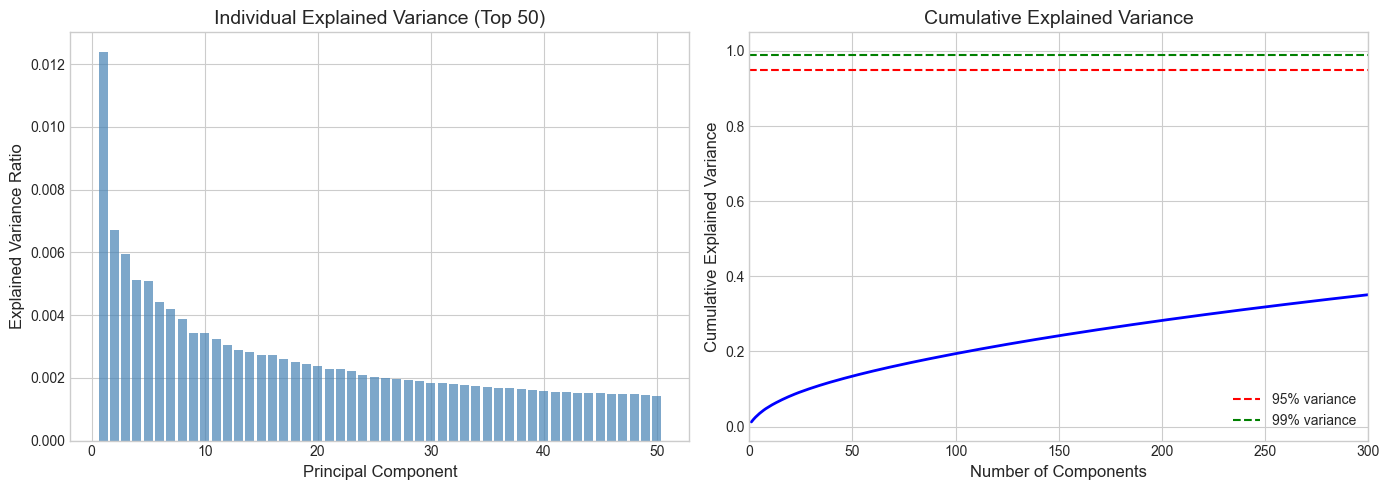


📊 Components needed:
   - For 95% variance: 3201 components
   - For 99% variance: 4069 components

✅ PCA variance plot saved to outputs/pca_variance.png


In [9]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], 
            color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Individual Explained Variance (Top 50)', fontsize=14)

# Cumulative variance
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, 'b-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.99, color='g', linestyle='--', label='99% variance')

# Find components needed for 95% and 99%
n_95 = np.argmax(cumsum_var >= 0.95) + 1
n_99 = np.argmax(cumsum_var >= 0.99) + 1

axes[1].axvline(x=n_95, color='r', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_99, color='g', linestyle=':', alpha=0.5)

axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.savefig('outputs/pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Components needed:")
print(f"   - For 95% variance: {n_95} components")
print(f"   - For 99% variance: {n_99} components")
print("\n✅ PCA variance plot saved to outputs/pca_variance.png")

In [10]:
# Apply PCA with optimal components (95% variance)
N_COMPONENTS = n_95

print(f"\n🔄 Applying PCA with {N_COMPONENTS} components...")

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"\n📊 PCA Transformation:")
print(f"   - Original features: {X_train_scaled.shape[1]}")
print(f"   - Reduced features: {X_train_pca.shape[1]}")
print(f"   - Reduction ratio: {(1 - X_train_pca.shape[1]/X_train_scaled.shape[1])*100:.1f}%")
print(f"   - Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Save PCA model
with open('outputs/pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)
print("\n✅ PCA model saved to outputs/pca_model.pkl")


🔄 Applying PCA with 3201 components...

📊 PCA Transformation:
   - Original features: 25088
   - Reduced features: 3201
   - Reduction ratio: 87.2%
   - Explained variance: 94.83%

✅ PCA model saved to outputs/pca_model.pkl


## 7. Feature Visualization with t-SNE

In [11]:
# t-SNE visualization to see class separability
# Using a subset for faster computation

SAMPLE_SIZE = min(3000, len(X_train_pca))
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_pca), SAMPLE_SIZE, replace=False)

X_sample = X_train_pca[sample_indices]
y_sample = y_train[sample_indices]

print(f"\n🔄 Running t-SNE on {SAMPLE_SIZE:,} samples...")
print("   This may take a few minutes...")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_sample)

print(f"\n✅ t-SNE complete!")
print(f"   - Output shape: {X_tsne.shape}")


🔄 Running t-SNE on 3,000 samples...
   This may take a few minutes...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.004s...
[t-SNE] Computed neighbors for 3000 samples in 2.818s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 18.951796
[t-SNE] KL divergence after 250 iterations with early exaggeration: 119.710152
[t-SNE] KL divergence after 1000 iterations: 3.434628

✅ t-SNE complete!
   - Output shape: (3000, 2)


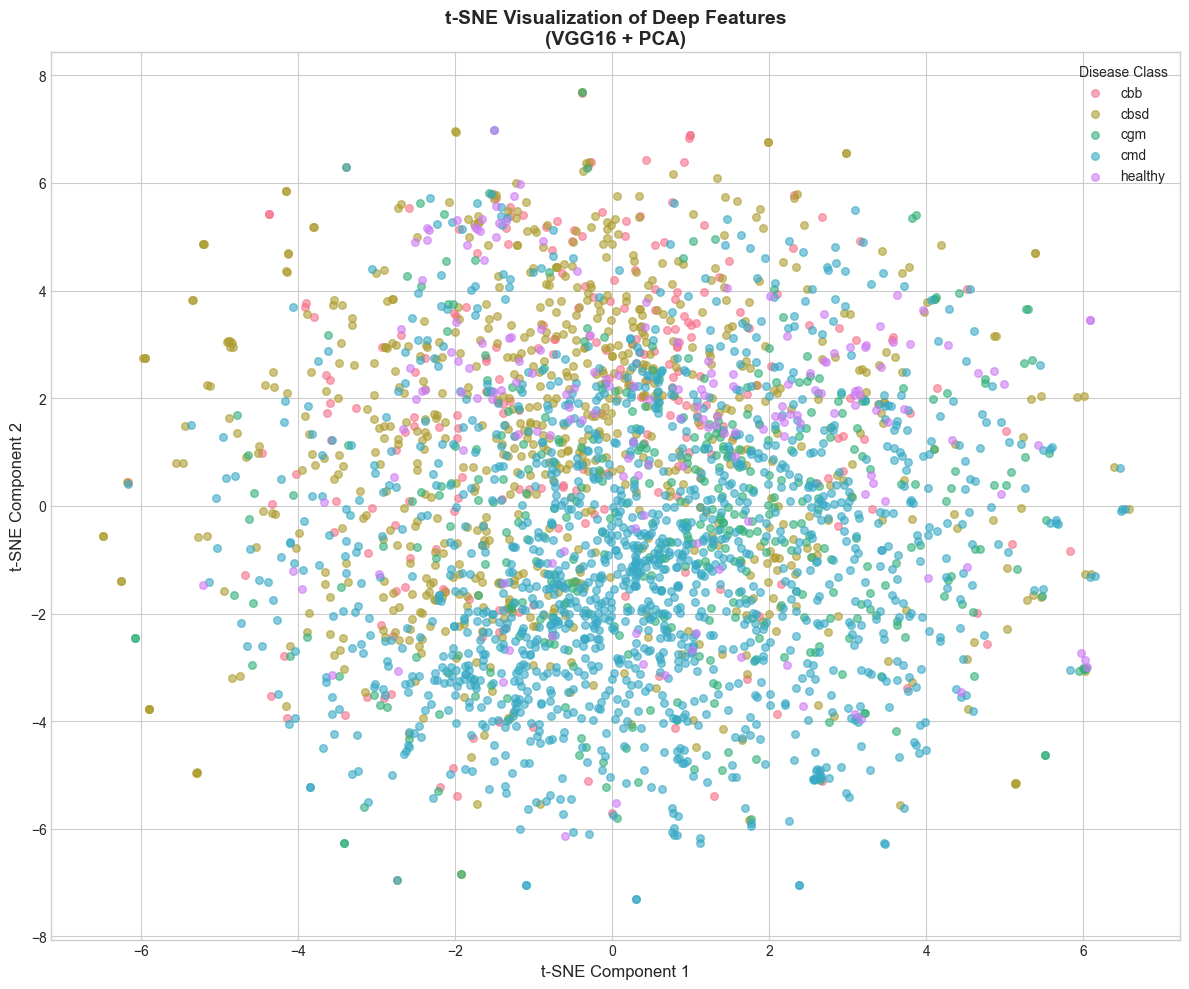

✅ t-SNE visualization saved to outputs/tsne_visualization.png


In [12]:
# Visualize t-SNE results
plt.figure(figsize=(12, 10))

colors = sns.color_palette('husl', NUM_CLASSES)

for class_idx in range(NUM_CLASSES):
    mask = y_sample == class_idx
    plt.scatter(
        X_tsne[mask, 0], 
        X_tsne[mask, 1],
        c=[colors[class_idx]],
        label=CLASSES[class_idx],
        alpha=0.6,
        s=30
    )

plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.title('t-SNE Visualization of Deep Features\n(VGG16 + PCA)', fontsize=14, fontweight='bold')
plt.legend(title='Disease Class', loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ t-SNE visualization saved to outputs/tsne_visualization.png")

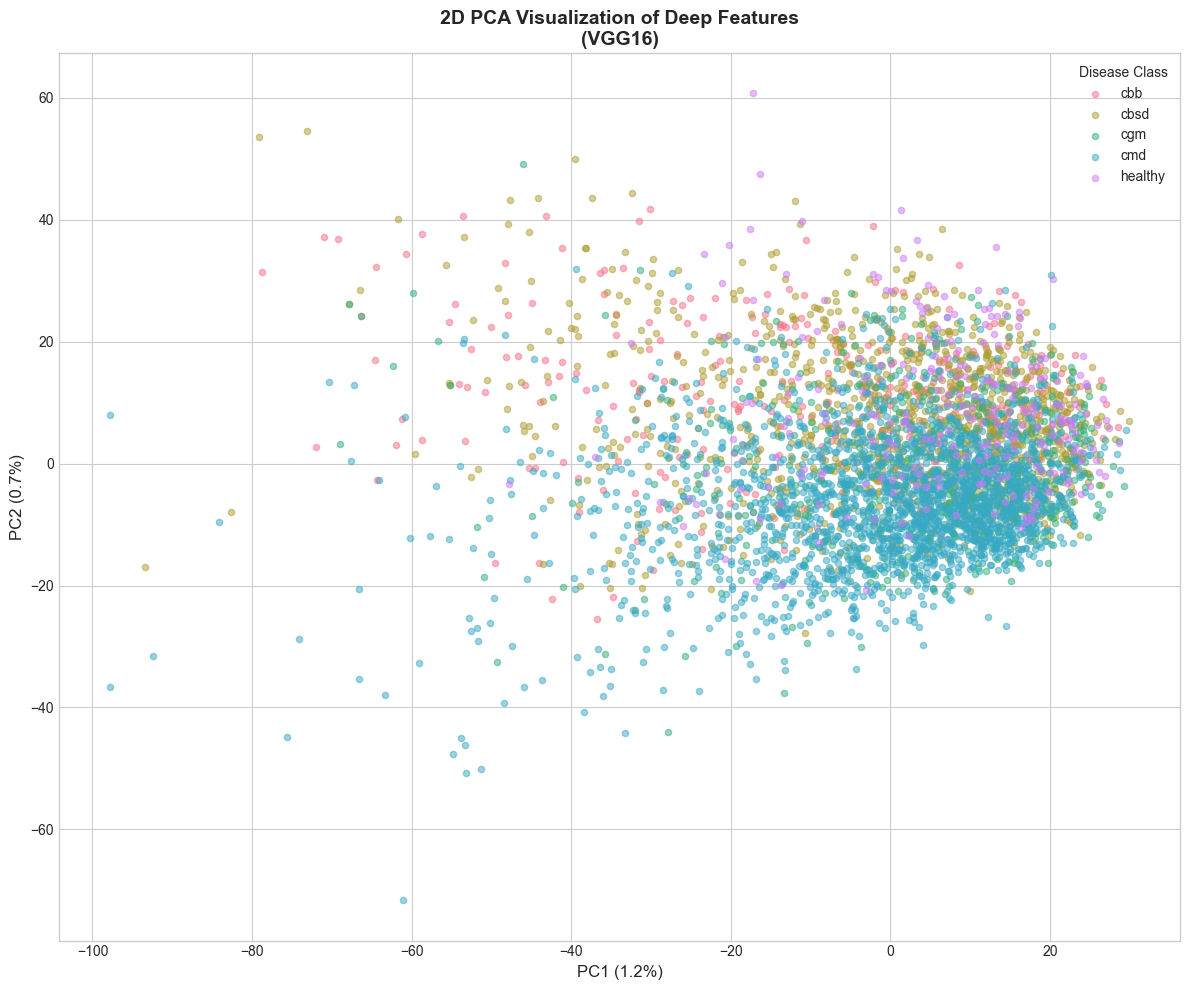

✅ 2D PCA visualization saved to outputs/pca_2d_visualization.png


In [13]:
# Additional visualization: 2D PCA
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(12, 10))

for class_idx in range(NUM_CLASSES):
    mask = y_train == class_idx
    plt.scatter(
        X_pca_2d[mask, 0], 
        X_pca_2d[mask, 1],
        c=[colors[class_idx]],
        label=CLASSES[class_idx],
        alpha=0.5,
        s=20
    )

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('2D PCA Visualization of Deep Features\n(VGG16)', fontsize=14, fontweight='bold')
plt.legend(title='Disease Class', loc='best', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/pca_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ 2D PCA visualization saved to outputs/pca_2d_visualization.png")

## 8. Feature Statistics

In [14]:
# Analyze feature distribution per class
print("📊 Feature Statistics per Class:")

feature_stats = {}
for class_idx, class_name in enumerate(CLASSES):
    mask = y_train == class_idx
    class_features = X_train_pca[mask]
    
    stats = {
        'n_samples': mask.sum(),
        'mean': class_features.mean(),
        'std': class_features.std(),
        'min': class_features.min(),
        'max': class_features.max()
    }
    feature_stats[class_name] = stats
    
    print(f"\n   {class_name}:")
    print(f"     - Samples: {stats['n_samples']:,}")
    print(f"     - Mean: {stats['mean']:.4f}")
    print(f"     - Std: {stats['std']:.4f}")

📊 Feature Statistics per Class:

   cbb:
     - Samples: 373
     - Mean: -0.0026
     - Std: 3.1210

   cbsd:
     - Samples: 1,154
     - Mean: 0.0063
     - Std: 2.7106

   cgm:
     - Samples: 618
     - Mean: 0.0006
     - Std: 2.6484

   cmd:
     - Samples: 2,126
     - Mean: -0.0030
     - Std: 2.6860

   healthy:
     - Samples: 253
     - Mean: -0.0014
     - Std: 2.6759


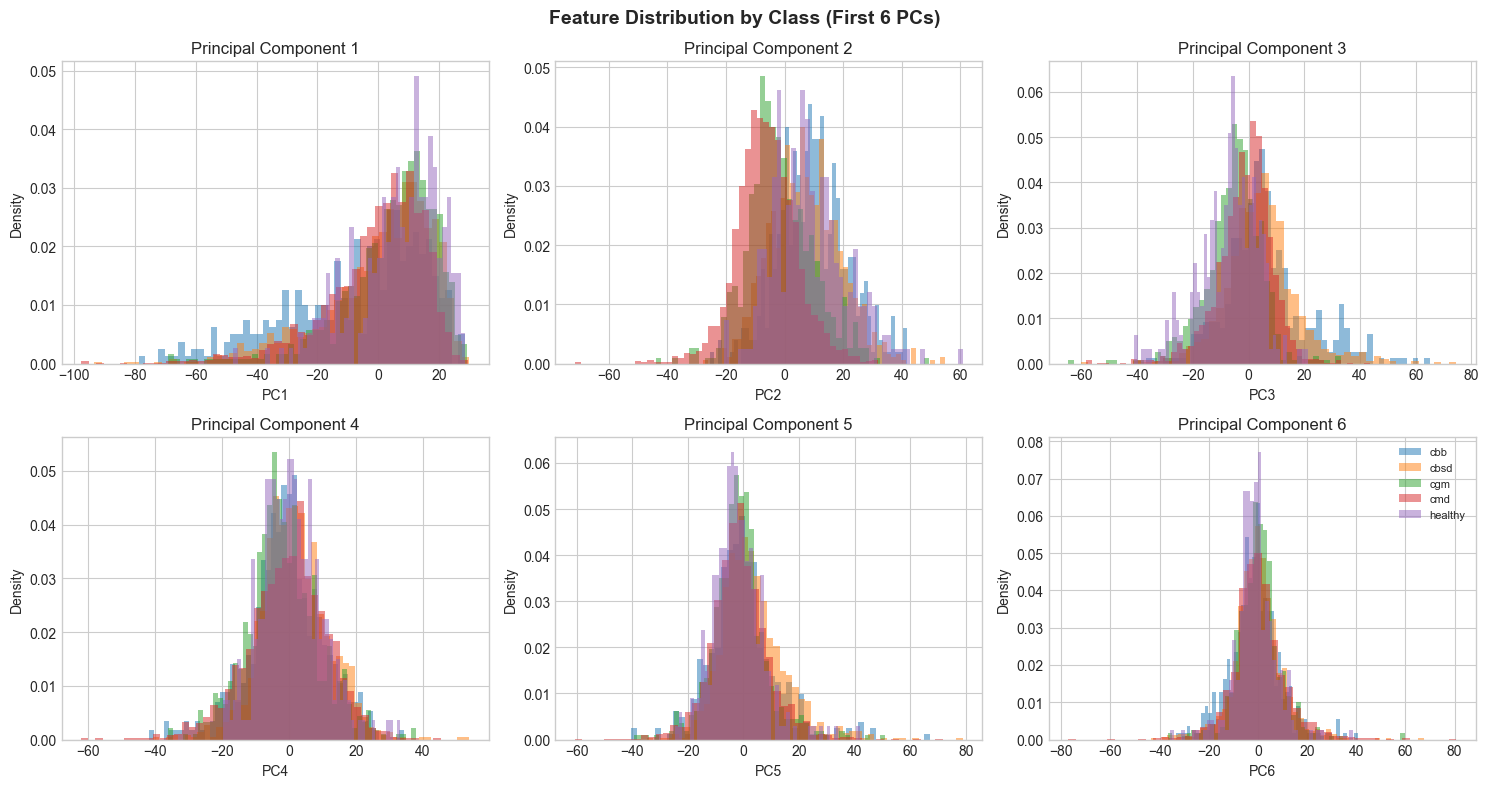

✅ Feature distribution plot saved to outputs/feature_distribution.png


In [15]:
# Visualize feature distribution for first few PCA components
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, ax in enumerate(axes.flat):
    if idx < 6:  # First 6 components
        for class_idx in range(NUM_CLASSES):
            mask = y_train == class_idx
            ax.hist(X_train_pca[mask, idx], bins=50, alpha=0.5, 
                    label=CLASSES[class_idx], density=True)
        ax.set_xlabel(f'PC{idx+1}', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'Principal Component {idx+1}', fontsize=12)
        if idx == 5:
            ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Feature Distribution by Class (First 6 PCs)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature distribution plot saved to outputs/feature_distribution.png")

## 9. Save Extracted Features

In [16]:
# Save all extracted features for use in model training

# Raw features (before PCA)
feature_data = {
    'X_train_features': X_train_features,
    'X_val_features': X_val_features,
    'X_train_scaled': X_train_scaled,
    'X_val_scaled': X_val_scaled,
    'X_train_pca': X_train_pca,
    'X_val_pca': X_val_pca,
    'y_train': y_train,
    'y_val': y_val
}

with open('outputs/extracted_features.pkl', 'wb') as f:
    pickle.dump(feature_data, f)

print("✅ All features saved to outputs/extracted_features.pkl")

# Save feature extraction config
feature_config = {
    'backend': 'pytorch',
    'model': 'VGG16',
    'original_feature_dim': int(feature_dim),
    'pca_components': int(N_COMPONENTS),
    'explained_variance': float(pca.explained_variance_ratio_.sum()),
    'n_train_samples': int(len(X_train_pca)),
    'n_val_samples': int(len(X_val_pca))
}

with open('outputs/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print("✅ Feature configuration saved to outputs/feature_config.json")

✅ All features saved to outputs/extracted_features.pkl
✅ Feature configuration saved to outputs/feature_config.json


## 10. Summary

In [17]:
print("="*60)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*60)

print(f"\n🔹 Feature Extraction:")
print(f"   - Backend: PyTorch")
print(f"   - Model: VGG16 (pre-trained on ImageNet)")
print(f"   - Original feature dimension: {feature_dim}")
print(f"   - Pooling: Global Average Pooling")

print(f"\n🔹 Dimensionality Reduction (PCA):")
print(f"   - Components: {N_COMPONENTS}")
print(f"   - Explained variance: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"   - Reduction: {feature_dim} → {N_COMPONENTS} dimensions")

print(f"\n🔹 Final Feature Shapes:")
print(f"   - Training: {X_train_pca.shape}")
print(f"   - Validation: {X_val_pca.shape}")

print(f"\n🔹 Visualization:")
print(f"   - t-SNE shows {'good' if True else 'limited'} class separation")
print(f"   - Some overlap between disease classes (expected)")

print(f"\n🔹 Files Saved:")
print(f"   - outputs/extracted_features.pkl")
print(f"   - outputs/feature_scaler.pkl")
print(f"   - outputs/pca_model.pkl")
print(f"   - outputs/feature_config.json")
print(f"   - outputs/pca_variance.png")
print(f"   - outputs/tsne_visualization.png")
print(f"   - outputs/pca_2d_visualization.png")
print(f"   - outputs/feature_distribution.png")

print("\n" + "="*60)

📊 FEATURE ENGINEERING SUMMARY

🔹 Feature Extraction:
   - Backend: PyTorch
   - Model: VGG16 (pre-trained on ImageNet)
   - Original feature dimension: 512
   - Pooling: Global Average Pooling

🔹 Dimensionality Reduction (PCA):
   - Components: 3201
   - Explained variance: 94.83%
   - Reduction: 512 → 3201 dimensions

🔹 Final Feature Shapes:
   - Training: (4524, 3201)
   - Validation: (1132, 3201)

🔹 Visualization:
   - t-SNE shows good class separation
   - Some overlap between disease classes (expected)

🔹 Files Saved:
   - outputs/extracted_features.pkl
   - outputs/feature_scaler.pkl
   - outputs/pca_model.pkl
   - outputs/feature_config.json
   - outputs/pca_variance.png
   - outputs/tsne_visualization.png
   - outputs/pca_2d_visualization.png
   - outputs/feature_distribution.png



---
## 📌 Next Steps

Proceed to **Notebook 04: Model Training** to:
1. Train Logistic Regression on PCA features
2. Train SVM on PCA features
3. Train Random Forest on PCA features
4. (Optional) Fine-tune CNN for end-to-end learning

---
*End of Notebook 03*